# Лабораторная работа №2. Временные ряды

## Чтение и восстановаление данных

In [59]:
import pandas as pd

In [60]:
xl = pd.ExcelFile("./data/have_fun.xlsx")

Исправление кодировок: "iso-8859-1" -> "windows-1251".

In [61]:
encoded_sheet_names = xl.sheet_names
decoded_sheet_names = [x.encode("iso-8859-1").decode("windows-1251") for x in encoded_sheet_names]

print(encoded_sheet_names)
print(decoded_sheet_names)

['Ëèñò1', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']
['Лист1', 'Лист2_строковые_NaN_выбросы', 'Лист3_смешанные_типы']


В инттерфейсе MS Exle: были найдены скрытые листы, установлен парамент "Показать".
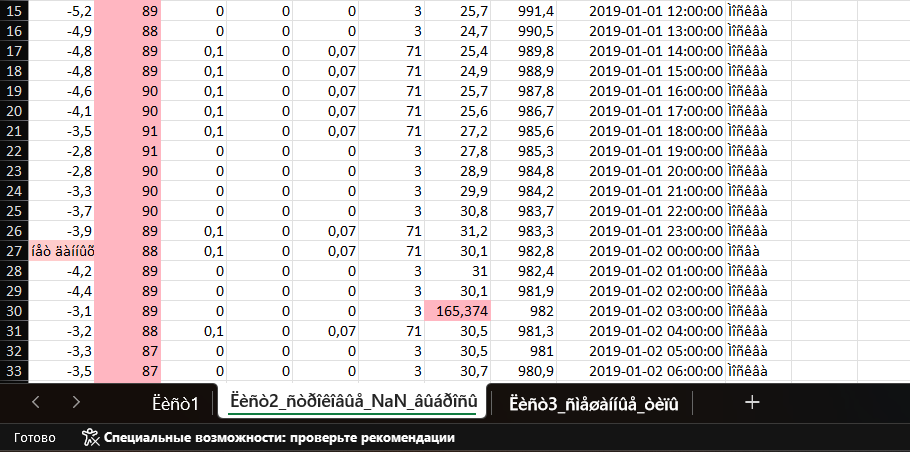

In [62]:
df_sheets = [xl.parse(sheet_name=name) for name in encoded_sheet_names]

In [63]:
df_sheets[0].info()

<class 'pandas.DataFrame'>
RangeIndex: 125124 entries, 0 to 125123
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        123249 non-null  float64       
 1   relative_humidity_2m  125124 non-null  int64         
 2   precipitation         123877 non-null  float64       
 3   rain                  125124 non-null  float64       
 4   snowfall              125124 non-null  float64       
 5   weathercode           125124 non-null  int64         
 6   wind_speed_10m        123872 non-null  float64       
 7   surface_pressure      125124 non-null  float64       
 8   ds                    125124 non-null  datetime64[us]
 9   city                  125124 non-null  str           
dtypes: datetime64[us](1), float64(6), int64(2), str(1)
memory usage: 9.5 MB


In [64]:
df_sheets[1].info()

<class 'pandas.DataFrame'>
RangeIndex: 125169 entries, 0 to 125168
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        122036 non-null  object        
 1   relative_humidity_2m  122715 non-null  float64       
 2   precipitation         122028 non-null  object        
 3   rain                  122715 non-null  float64       
 4   snowfall              122715 non-null  float64       
 5   weathercode           122714 non-null  float64       
 6   wind_speed_10m        122365 non-null  object        
 7   surface_pressure      122714 non-null  float64       
 8   ds                    122713 non-null  datetime64[us]
 9   city                  122712 non-null  str           
 10  Unnamed: 10           0 non-null       float64       
 11  Unnamed: 11           0 non-null       float64       
 12  Unnamed: 12           0 non-null       float64       
 13  Unnamed: 1

In [65]:
df_sheets[2].info()

<class 'pandas.DataFrame'>
RangeIndex: 122736 entries, 0 to 122735
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        122731 non-null  object        
 1   relative_humidity_2m  122731 non-null  float64       
 2   precipitation         122487 non-null  object        
 3   rain                  122736 non-null  float64       
 4   snowfall              122736 non-null  float64       
 5   weathercode           122736 non-null  object        
 6   wind_speed_10m        122736 non-null  object        
 7   surface_pressure      122736 non-null  float64       
 8   ds                    122736 non-null  datetime64[us]
 9   city                  122736 non-null  str           
dtypes: datetime64[us](1), float64(4), object(4), str(1)
memory usage: 9.4+ MB


In [66]:
columns_sheets = [x.columns.to_list() for x in df_sheets]

print(*columns_sheets, sep="\n")

['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']
['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24']
['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']


Первые 10 колонок совпадают, но в df_sheets[2] есть вылезший блок.

### Сдвигаем первый уехавший блок

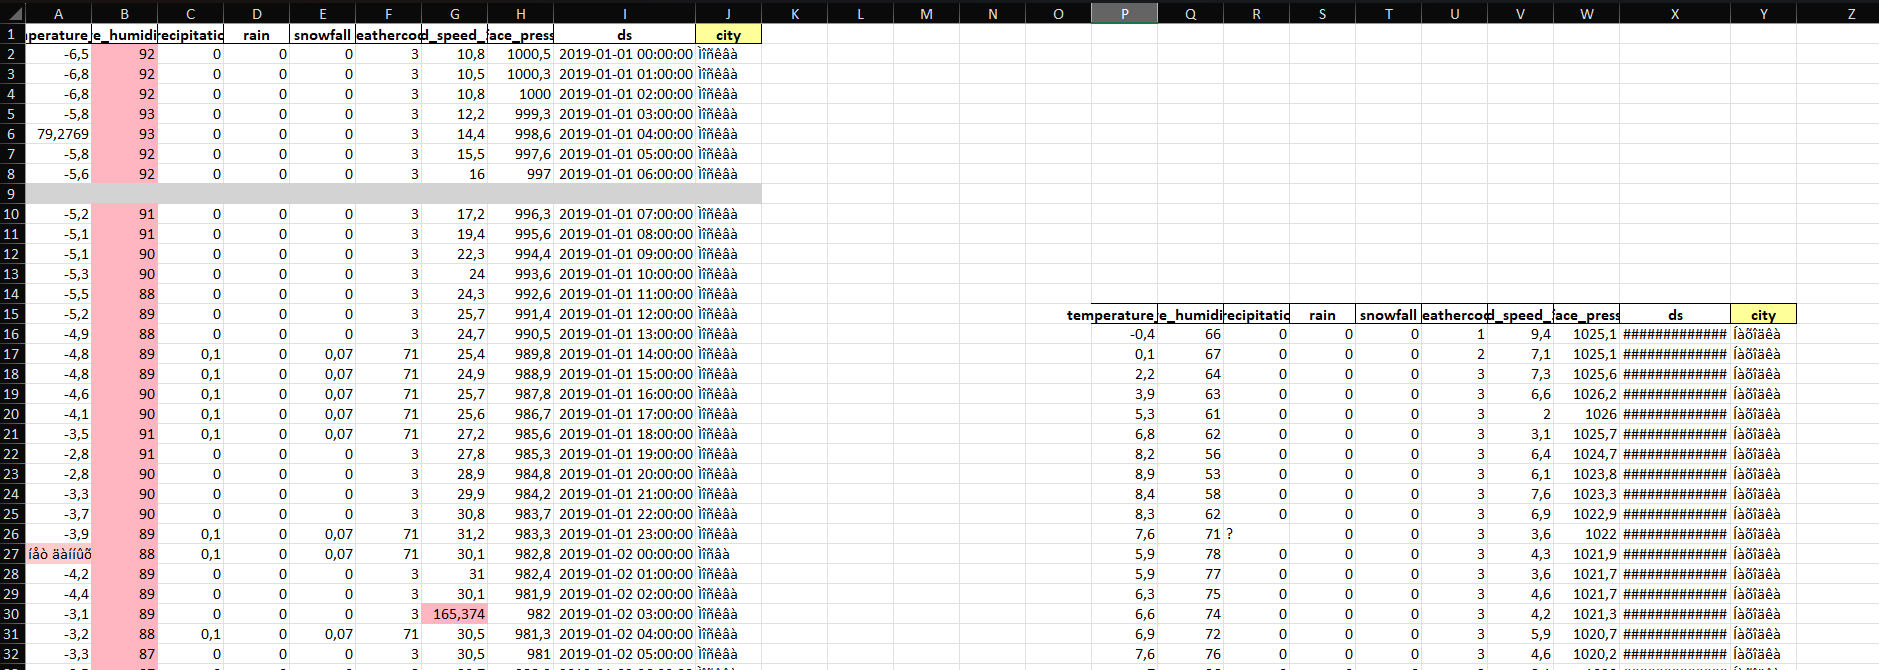
Он раскинулся не более чем на 200 первых строк.

In [67]:
print(columns_sheets[1].index("Unnamed: 15"))

df_sheets[1].iloc[13:18, 10:] # Подобрано опытным путём

15


,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
13,NaN,NaN,NaN,NaN,NaN,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
14,NaN,NaN,NaN,NaN,NaN,-0.4,66,0,0,0,1,9.4,1025.099976,2022-11-11 07:00:00,Íàõîäêà
15,NaN,NaN,NaN,NaN,NaN,0.1,67,0,0,0,2,7.1,1025.099976,2022-11-11 08:00:00,Íàõîäêà
16,NaN,NaN,NaN,NaN,NaN,2.2,64,0,0,0,3,7.3,1025.599976,2022-11-11 09:00:00,Íàõîäêà
17,NaN,NaN,NaN,NaN,NaN,3.9,63,0,0,0,3,6.6,1026.199951,2022-11-11 10:00:00,Íàõîäêà


Заметим, что съехаваший блок начинается с колонки "Unnamed: 15"

In [68]:
column_with_data = df_sheets[1].iloc[:200, 15]

start_row = column_with_data.first_valid_index()
end_row = column_with_data.last_valid_index()


broken_df = df_sheets[1].iloc[start_row + 1: end_row + 1, 15:]

broken_df.columns = df_sheets[0].columns # Устанавливаем правильный заголовок

df_sheets.append(broken_df)

### Сдвигаем второй уехавший блок

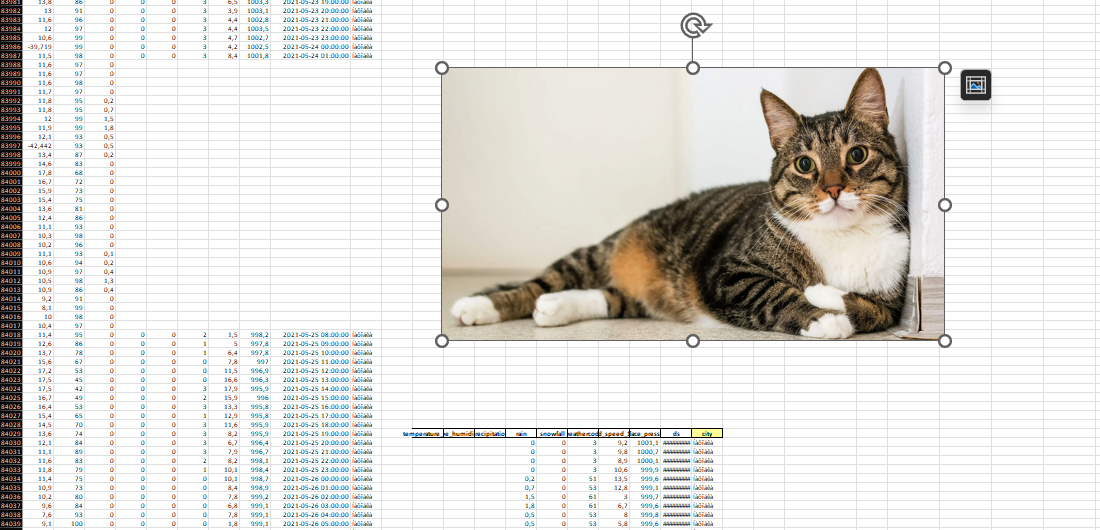    
После ручного сдвига:  
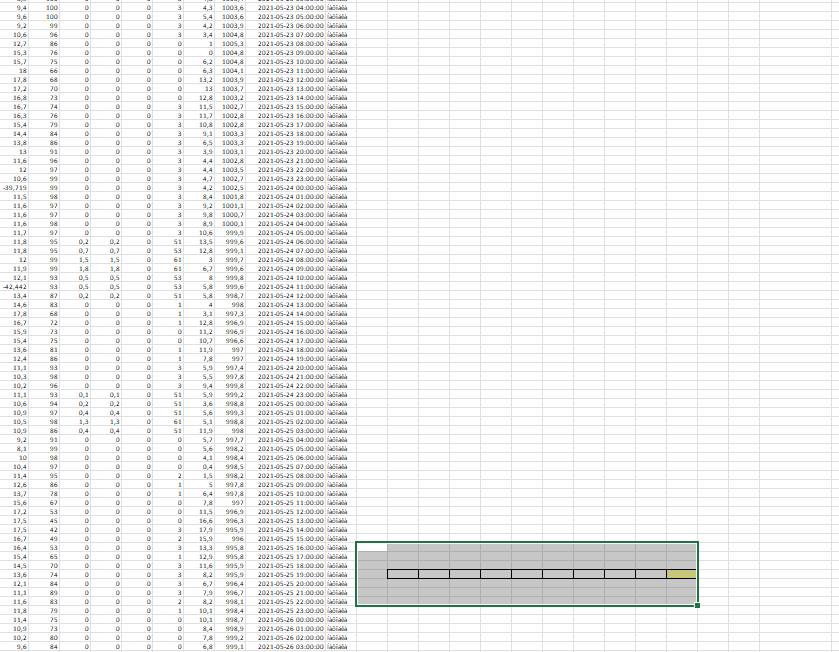

Удалим лишние столбцы из df_sheets[1].

In [69]:
df_sheets[1] = df_sheets[1].iloc[:, 0:10]

Объединим все в один df.

In [70]:
df_concated = pd.concat(df_sheets, ignore_index=True)

Приводим к правильным типам.

In [71]:
print(df_concated.columns.to_list())

['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']


Следующие колонки должны иметь числовой тип:
* temperature_2m
* relative_humidity_2m
* precipitation
* rain
* snowfall
* weathercode
* wind_speed_10m
* surface_pressure

In [72]:
numeric_cols = ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure']

for col in numeric_cols:
    df_concated[col] = pd.to_numeric(df_concated[col], errors="coerce")

df_concated["ds"] = pd.to_datetime(df_concated["ds"])

In [73]:
df_concated.info()

<class 'pandas.DataFrame'>
RangeIndex: 373136 entries, 0 to 373135
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        366357 non-null  float64       
 1   relative_humidity_2m  370677 non-null  float64       
 2   precipitation         366976 non-null  float64       
 3   rain                  370682 non-null  float64       
 4   snowfall              370682 non-null  float64       
 5   weathercode           368840 non-null  float64       
 6   wind_speed_10m        367593 non-null  float64       
 7   surface_pressure      370681 non-null  float64       
 8   ds                    370680 non-null  datetime64[us]
 9   city                  370678 non-null  str           
dtypes: datetime64[us](1), float64(8), str(1)
memory usage: 28.5 MB


Удалим полностью пустые строки.

In [74]:
df_concated = df_concated.dropna(how="all")

## Исследование пропусков

In [75]:
colums = df_concated.columns.to_list()

missings = df_concated.isna().sum()
missing_percent = (df_concated.isna().sum() / len(df_concated)) * 100

report_df = pd.DataFrame({'count': missings, 'percent': missing_percent})
report_df = report_df.sort_values(by='count', ascending=False)

print(report_df)

                      count   percent
temperature_2m         4325  1.166768
precipitation          3706  0.999779
wind_speed_10m         3089  0.833329
weathercode            1842  0.496922
relative_humidity_2m      5  0.001349
city                      4  0.001079
ds                        2  0.000540
surface_pressure          1  0.000270
snowfall                  0  0.000000
rain                      0  0.000000


## Первичная обработка пропусков

Удалим строки, у которых есть пропуск в колонке город или время.

In [76]:
df_concated = df_concated.dropna(subset=["ds", "city"])

Восстановим кодировки.

In [77]:
df_concated["city"] = df_concated["city"].str.encode("iso-8859-1").str.decode("windows-1251")

In [78]:
df_concated["city"].unique()

<StringArray>
[      'Геленджик',    'Благовещенск',    'БЛАГОВЕЩЕНСК',     'Благовещенс',
   'Благовещенскк',    'благовещенск',       'ГЕЛЕНДЖИК',       'геленджик',
      'Геленджикк',        'Геленджи',          'Москва',           'Мосва',
         'Находка', 'Санкт-Петербург',            'Сочи',            'Сычи',
             'Счи',             'Соч']
Length: 18, dtype: str

In [79]:
city_correction = {
    'БЛАГОВЕЩЕНСК': 'Благовещенск',
    'благовещенск': 'Благовещенск',
    'Благовещенс': 'Благовещенск',
    'Благовещенскк': 'Благовещенск',
    
    'ГЕЛЕНДЖИК': 'Геленджик',
    'геленджик': 'Геленджик',
    'Геленджикк': 'Геленджик',
    'Геленджи': 'Геленджик',
    
    'Мосва': 'Москва',
    
    'Сычи': 'Сочи',
    'Счи': 'Сочи',
    'Соч': 'Сочи'
}

df_concated["city"] = df_concated["city"].replace(city_correction)

In [80]:
df_concated["city"].unique()

<StringArray>
['Геленджик', 'Благовещенск', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']
Length: 6, dtype: str

In [81]:
df_concated.head()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,3.800000,82.0,0.0,0.0,0.0,3.0,19.100000,1010.000000,2020-01-31 02:00:00,Геленджик
1,-3.000000,70.0,0.0,0.0,0.0,3.0,24.000000,981.900024,2025-02-28 09:00:00,Благовещенск
2,-1.300000,86.0,0.0,0.0,0.0,2.0,8.800000,1021.200012,2022-01-03 02:00:00,Геленджик
3,19.299999,49.0,0.0,0.0,0.0,0.0,22.799999,1016.200012,2020-09-17 06:00:00,Геленджик
4,9.600000,89.0,0.0,0.0,0.0,0.0,8.800000,1024.400024,2025-04-16 05:00:00,Геленджик


Сортируем сперва по городам, внутри них по дате и времени, а также температуре так, чтобы строки с реальными данными в случае дублей оказались выше.

In [82]:
df_concated = df_concated.sort_values(by=["city", "ds", "temperature_2m"])

Удаляем дубликаты если и город и время совпадает.

In [83]:
df_concated = df_concated.drop_duplicates(subset=['city', 'ds'], keep='first')

df_concated.reset_index(drop=True, inplace=True)

Исследуем количество пропущенных значений.

In [84]:
missing_times = df_concated.groupby('city')['ds'].diff().value_counts()

print(missing_times)

ds
0 days 01:00:00    368194
0 days 02:00:00         2
0 days 03:00:00         1
Name: count, dtype: int64


Приведем к гранулярности 1 час, добавив пустые строки.

In [85]:
# Устанавливаем дату как индекс, будут дубликаты индексов-дат для разных городов
df_resampled = df_concated.set_index('ds')

# Группируем по городу
# Создаем сетку с шагом 1 час
# Преобразуем временной ряд к заданной частоте 
df_resampled = df_resampled.groupby('city').resample('1h').asfreq()

# Убираем мульти-индекс
df_resampled = df_resampled.reset_index()

In [94]:
rename_dict = {
    'temperature_2m': 'temp_c',
    'relative_humidity_2m': 'humidity',
    'wind_speed_10m': 'wind_speed',
    'surface_pressure': 'pressure'
}
# Переименовываем
df_resampled = df_resampled.rename(columns=rename_dict)

Исследуем пропуски в ячейках.

In [115]:
import matplotlib.pyplot as plt

def plot_gaps_diagnostic(df, city_name, columns_to_plot, start_date=None, end_date=None):
    data = df[df['city'] == city_name].copy()
    data = data.sort_values('ds')
    
    if start_date:
        data = data[data['ds'] >= start_date]
    if end_date:
        data = data[data['ds'] <= end_date]
        
    n_cols = len(columns_to_plot)
    fig, axes = plt.subplots(nrows=n_cols, ncols=1, figsize=(15, 4 * n_cols), sharex=True)

    fig.suptitle(f'Анализ данных по городу: {city_name}', 
                 fontsize=20, 
                 fontweight='bold', 
                 y=1.02)
    
    if n_cols == 1:
        axes = [axes]
    
    for i, col in enumerate(columns_to_plot):
        ax = axes[i]
        
        ax.plot(data['ds'], data[col], color='steelblue', linewidth=1.5, 
                label='Данные')
        
        nan_points = data[data[col].isna()]
        
        if not nan_points.empty:
            y_pos = data[col].min()

            if pd.isna(y_pos):
                y_pos = 0
            
            ax.scatter(nan_points['ds'], [y_pos] * len(nan_points), 
                       color='red', marker='|', s=200, label=f'Обнаружен NaN: {nan_points.size} шт.', zorder=5)
        
        ax.set_title(f'Параметр: {col}', fontsize=12, loc='left')
        ax.grid(True, alpha=0.2)
        
        ax.legend(loc='upper right')

    plt.xlabel('Дата и время')
    plt.tight_layout()
    plt.show()

In [116]:
cities = df_resampled["city"].unique().tolist()

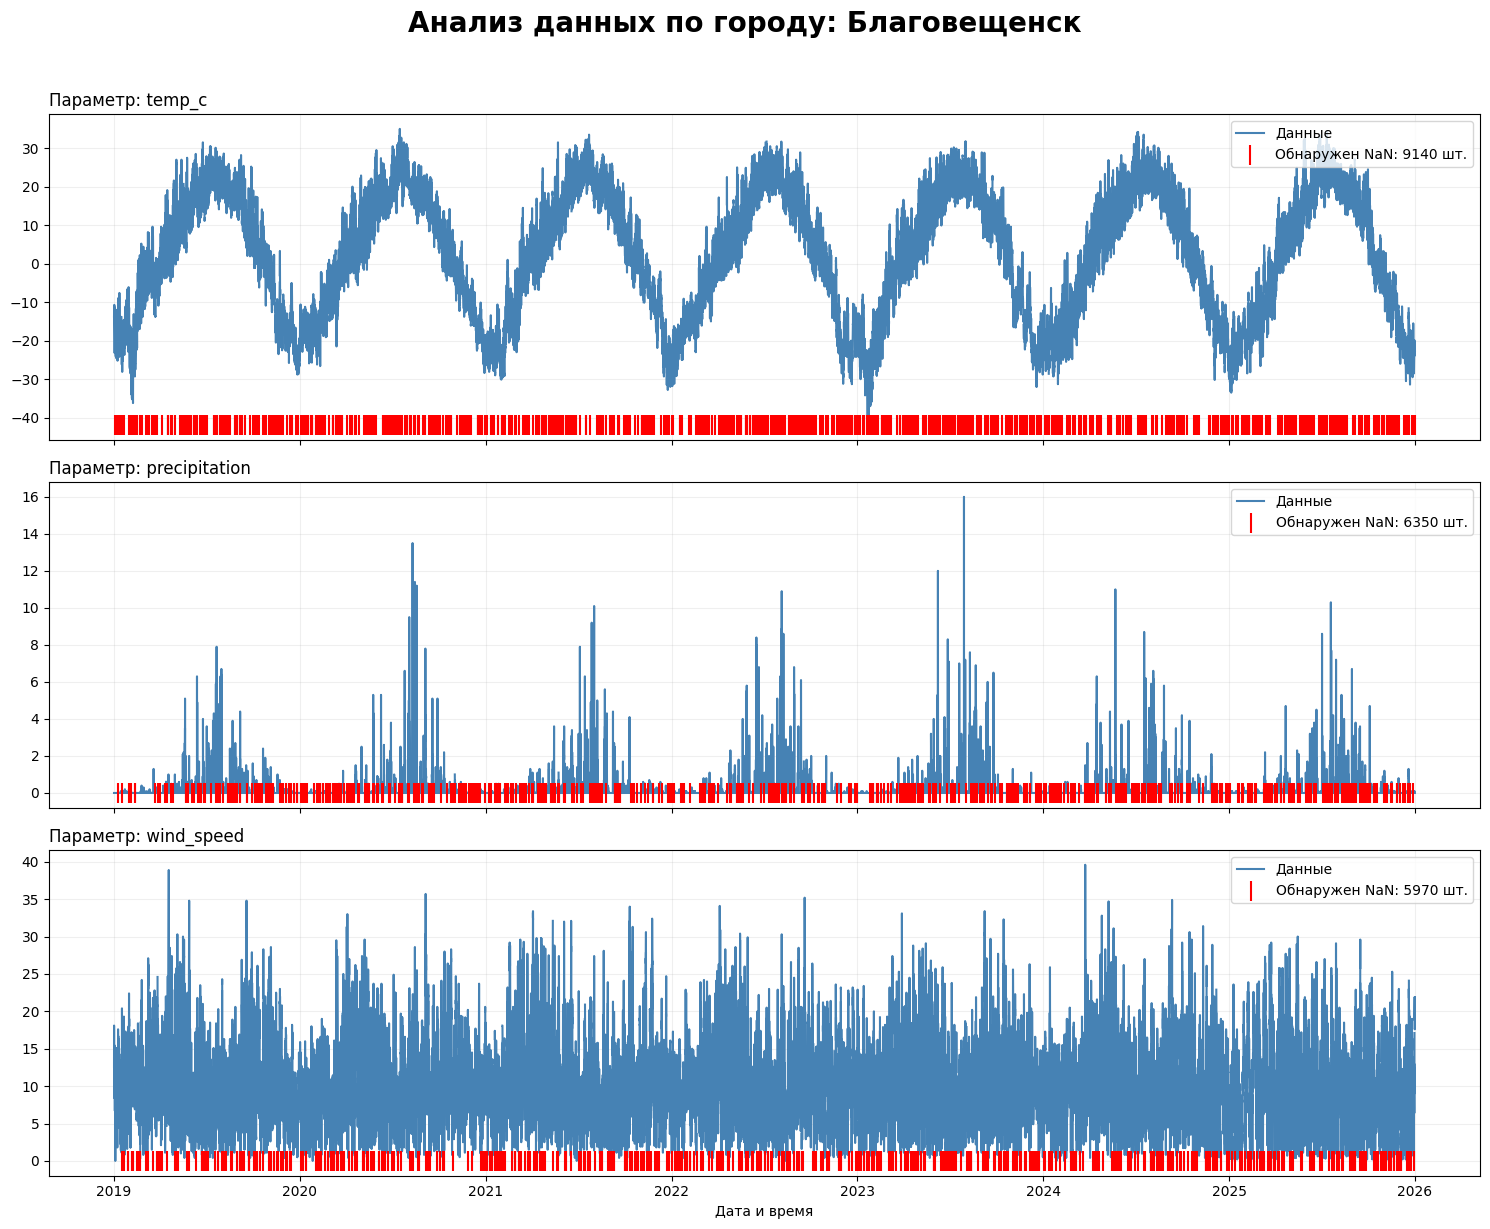

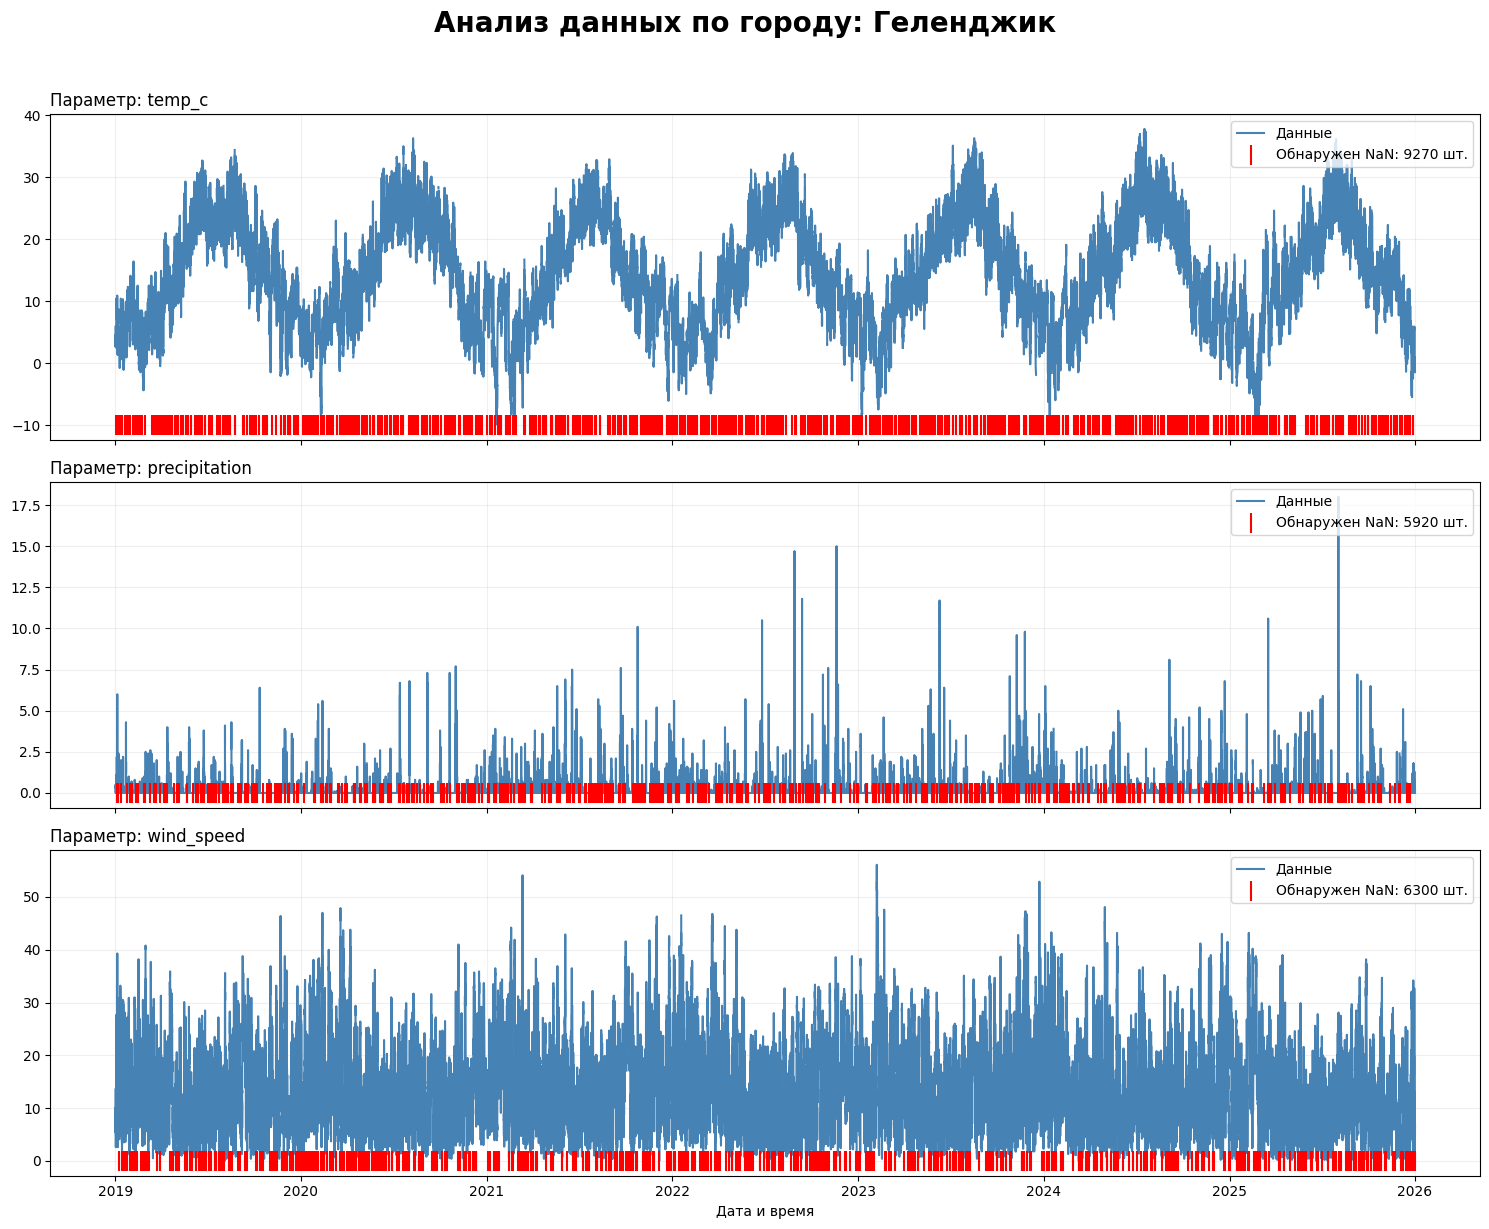

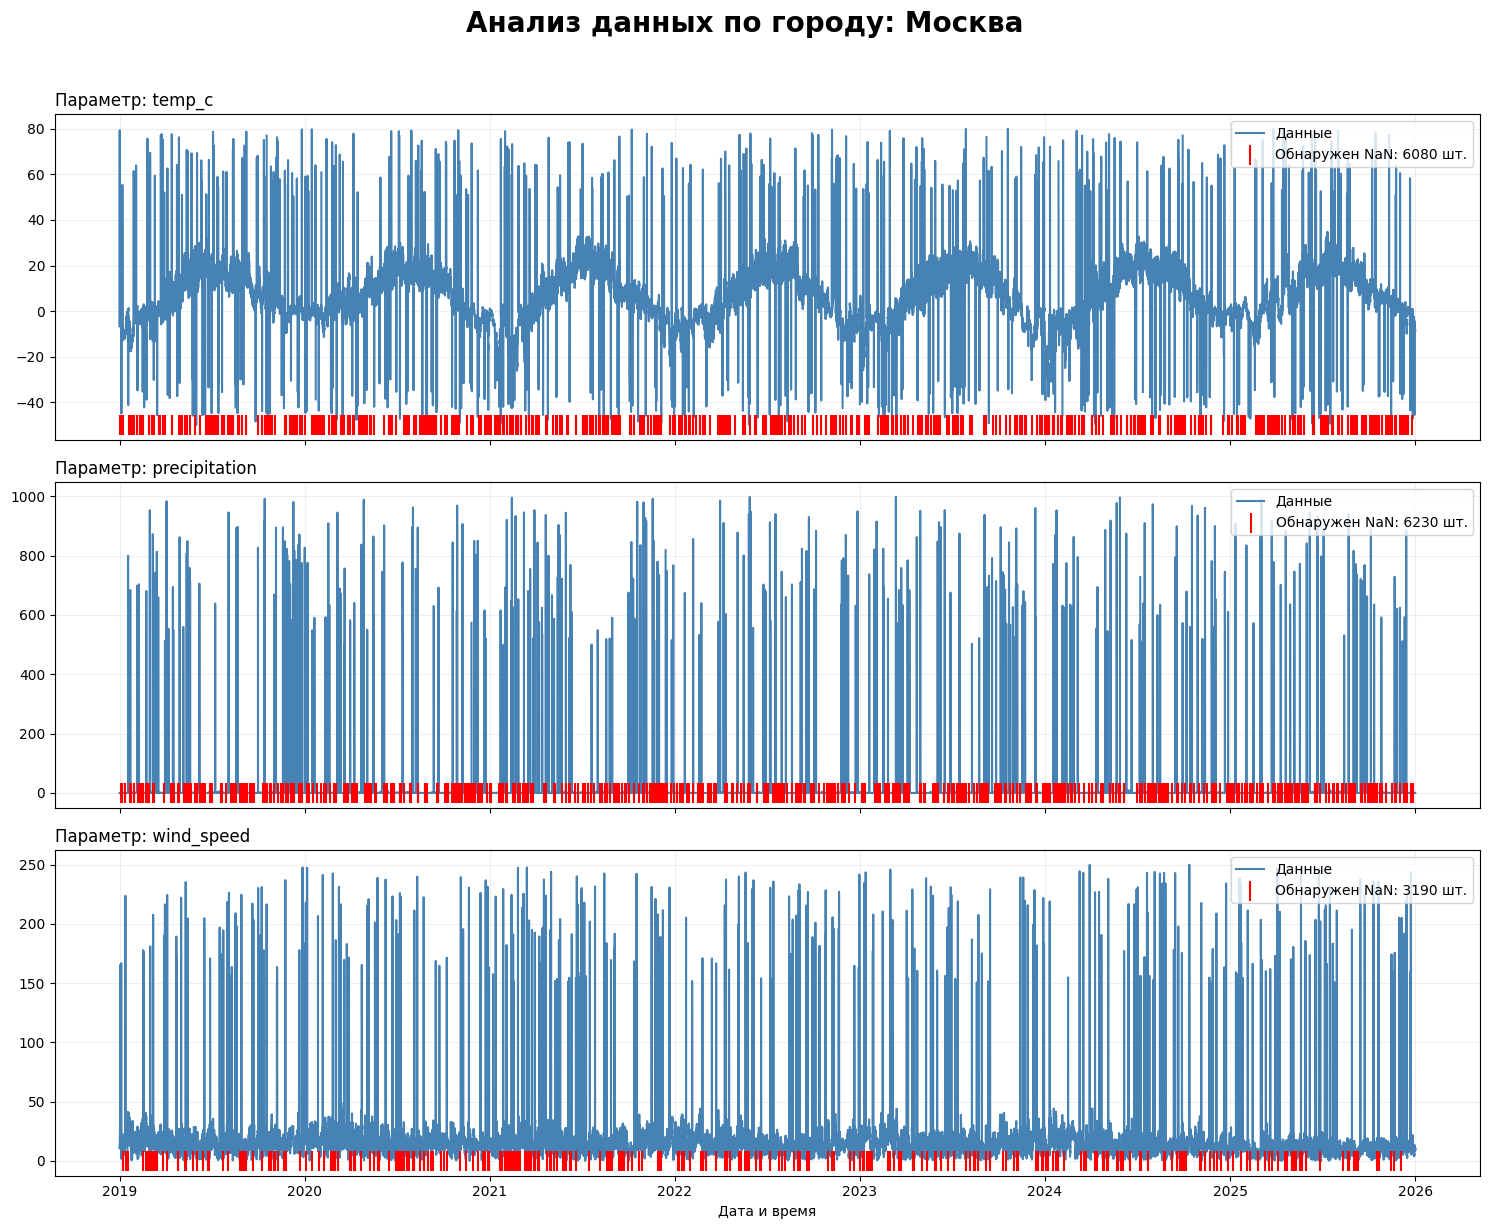

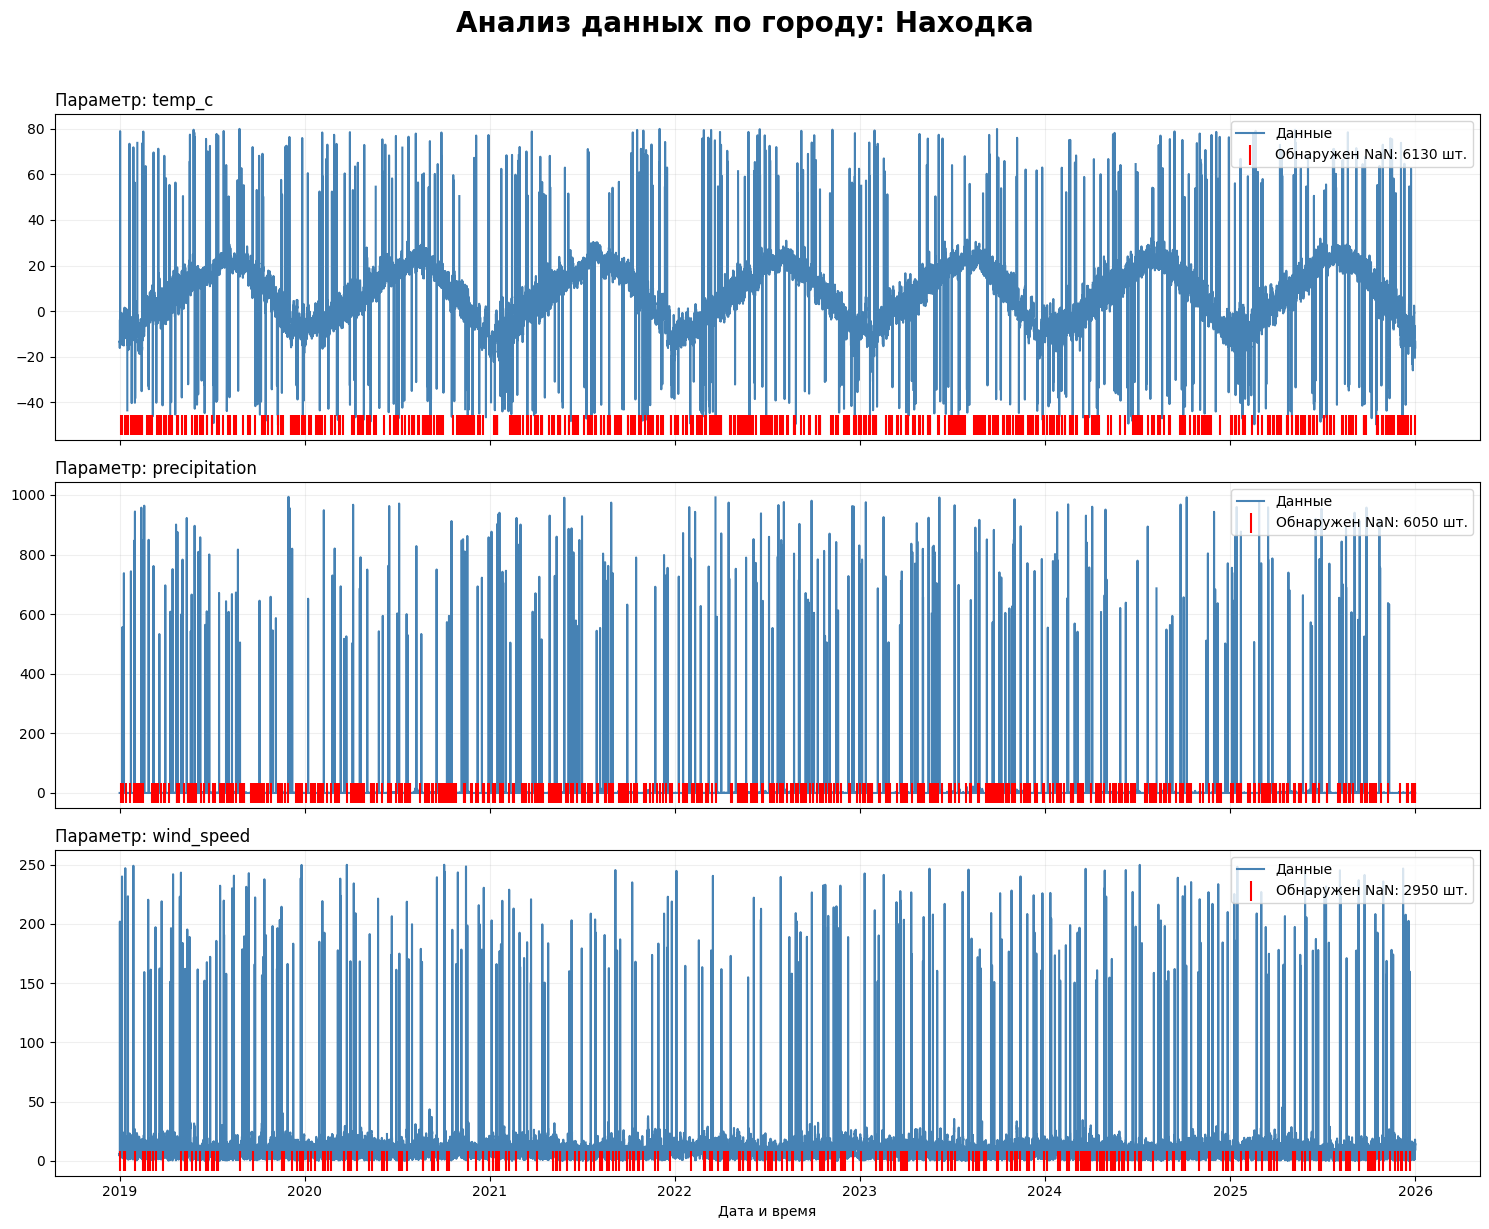

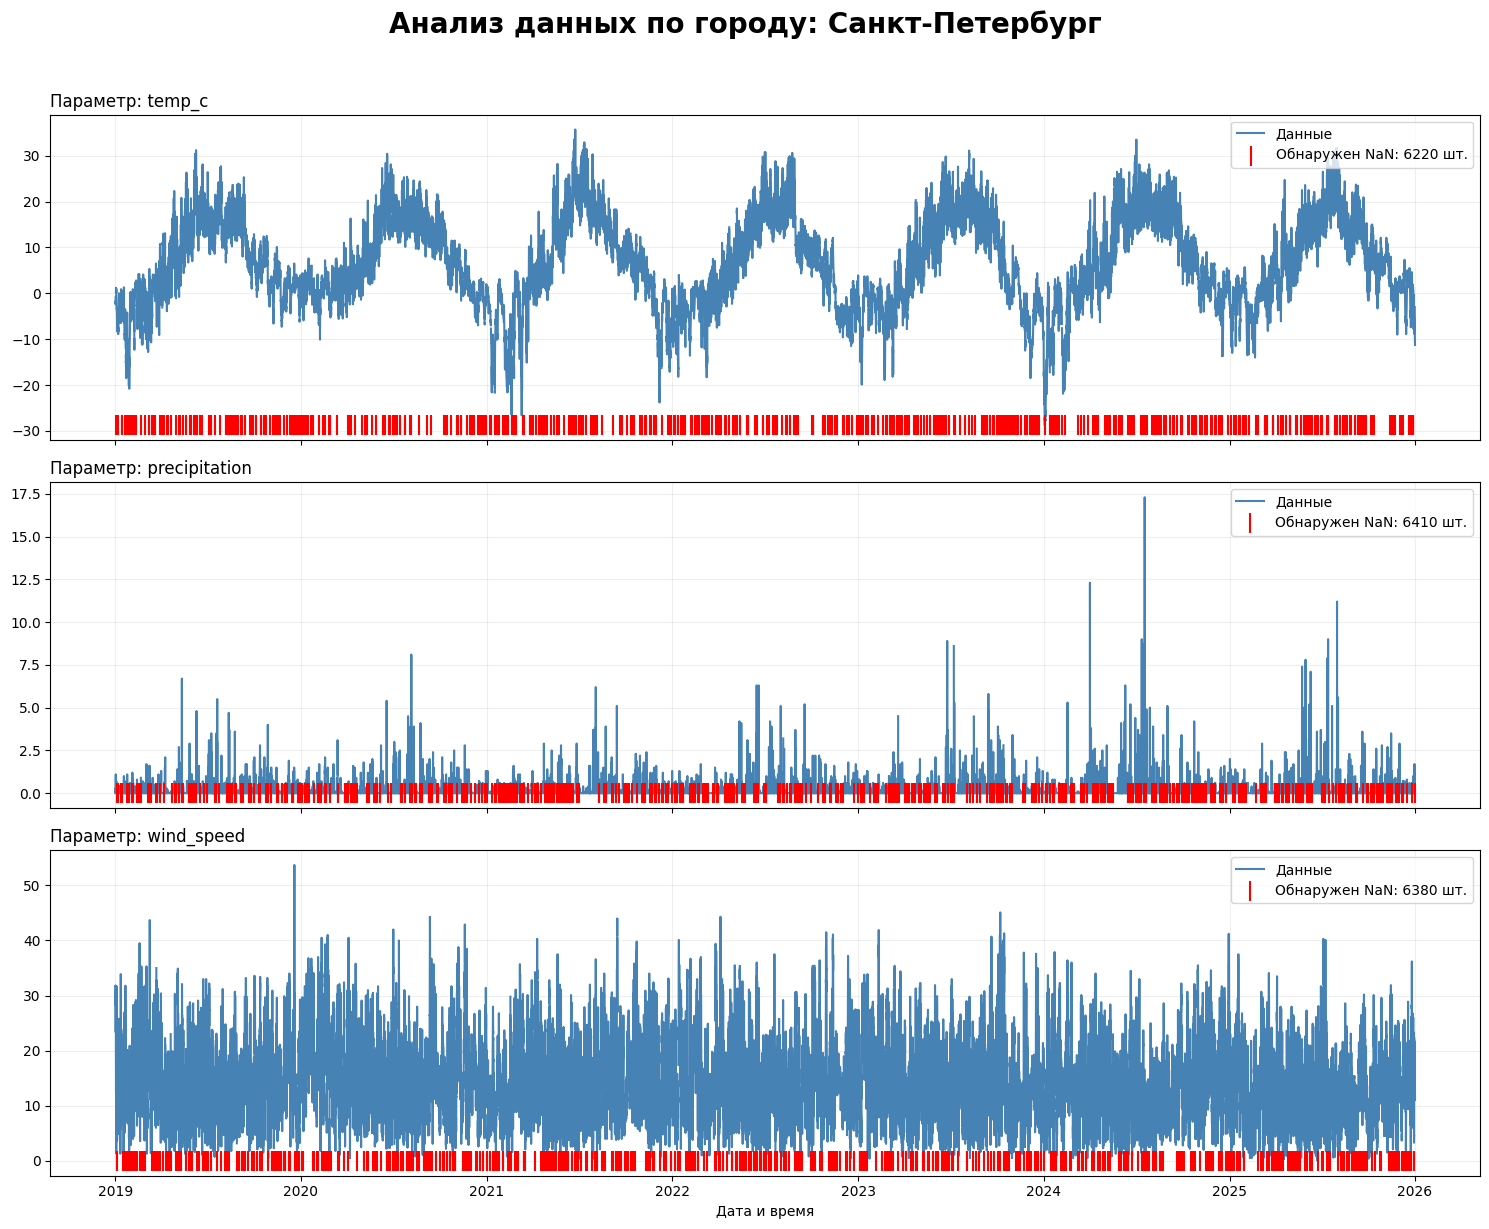

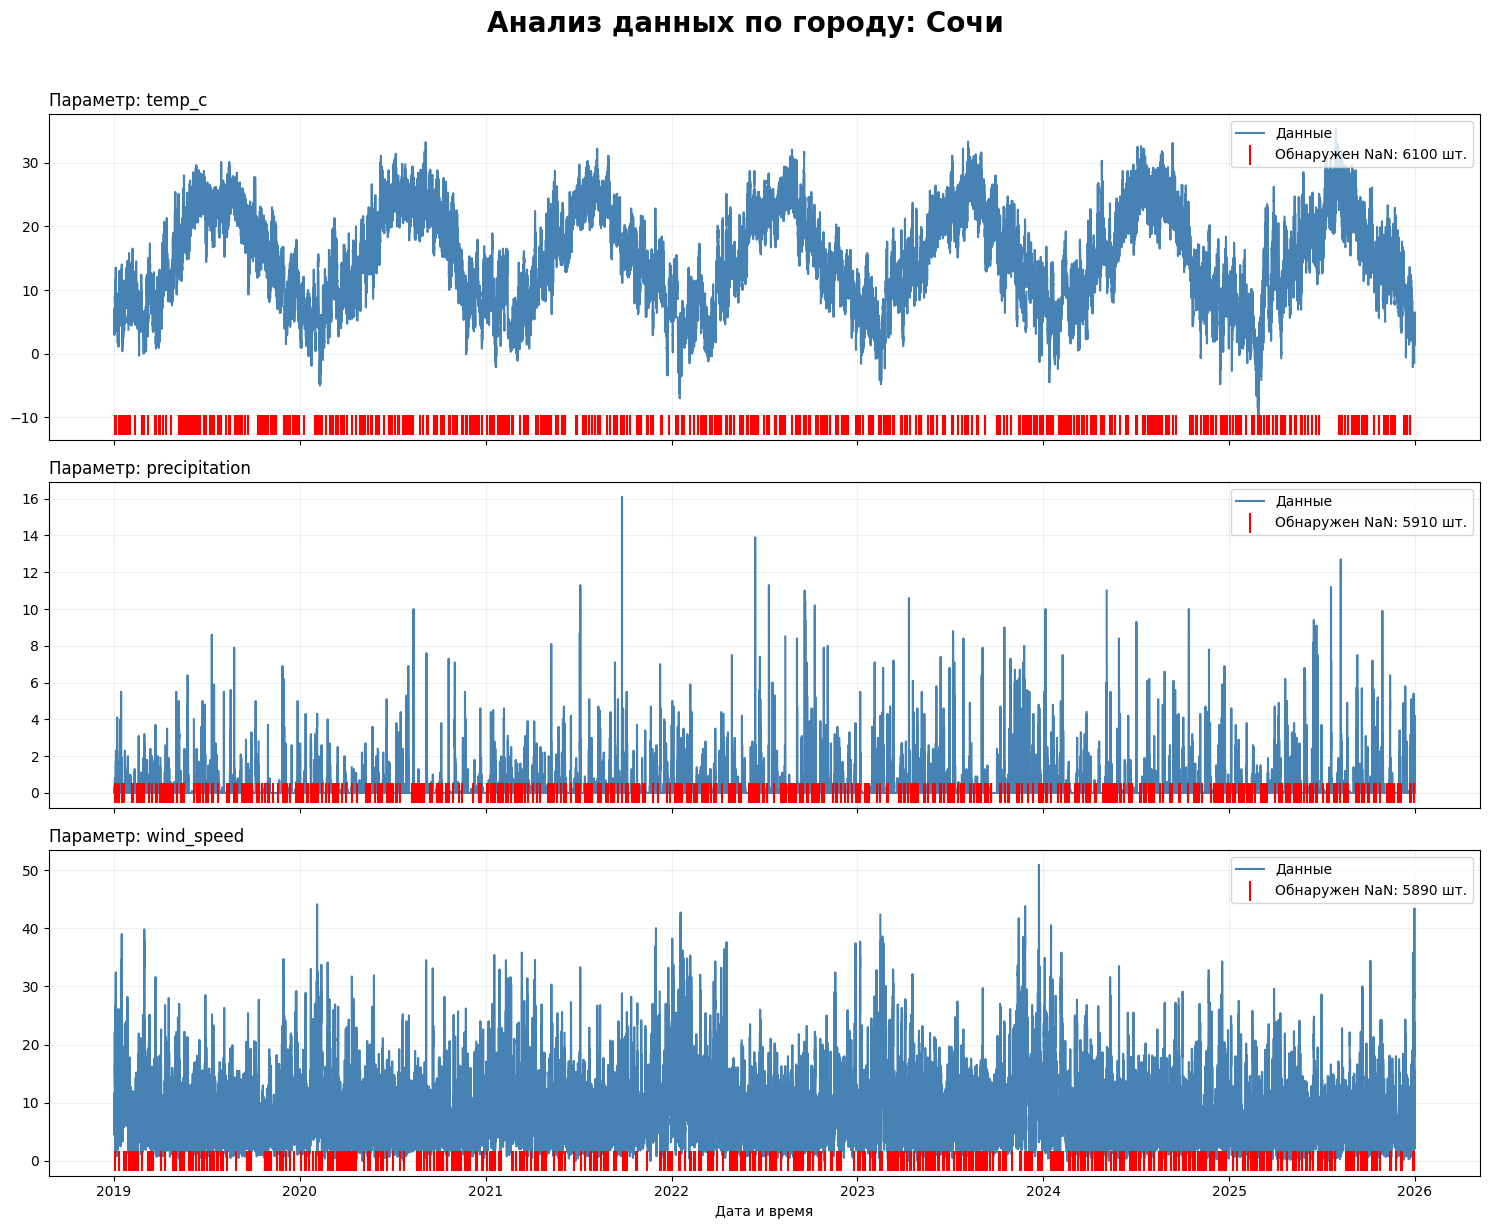

In [118]:
cols = ['temp_c', 'precipitation', 'wind_speed']

for city in cities:
    plot_gaps_diagnostic(df_resampled, city, cols) # '2019-01-01', '2024-02-28'

### Исследуем распределения

In [ ]:
import seaborn as sns
import math

def plot_single_city_diagnostic(df, city_name, columns):
    """
    Строит сетку боксплотов для всех параметров ОДНОГО конкретного города.
    """
    city_data = df[df['city'] == city_name]
    
    n_cols = 4
    n_rows = math.ceil(len(columns) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    fig.suptitle(f'Анализ выбросов: {city_name}', fontsize=20, fontweight='bold', y=1.02)
    
    axes_flat = axes.flatten()

    for i, col in enumerate(columns):
        ax = axes_flat[i]
        
        sns.boxplot(y=city_data[col], ax=ax)
        
        ax.set_title(f'{col}', fontsize=14)
        ax.set_ylabel('Значение')
        ax.grid(True, alpha=0.2, axis='y')

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

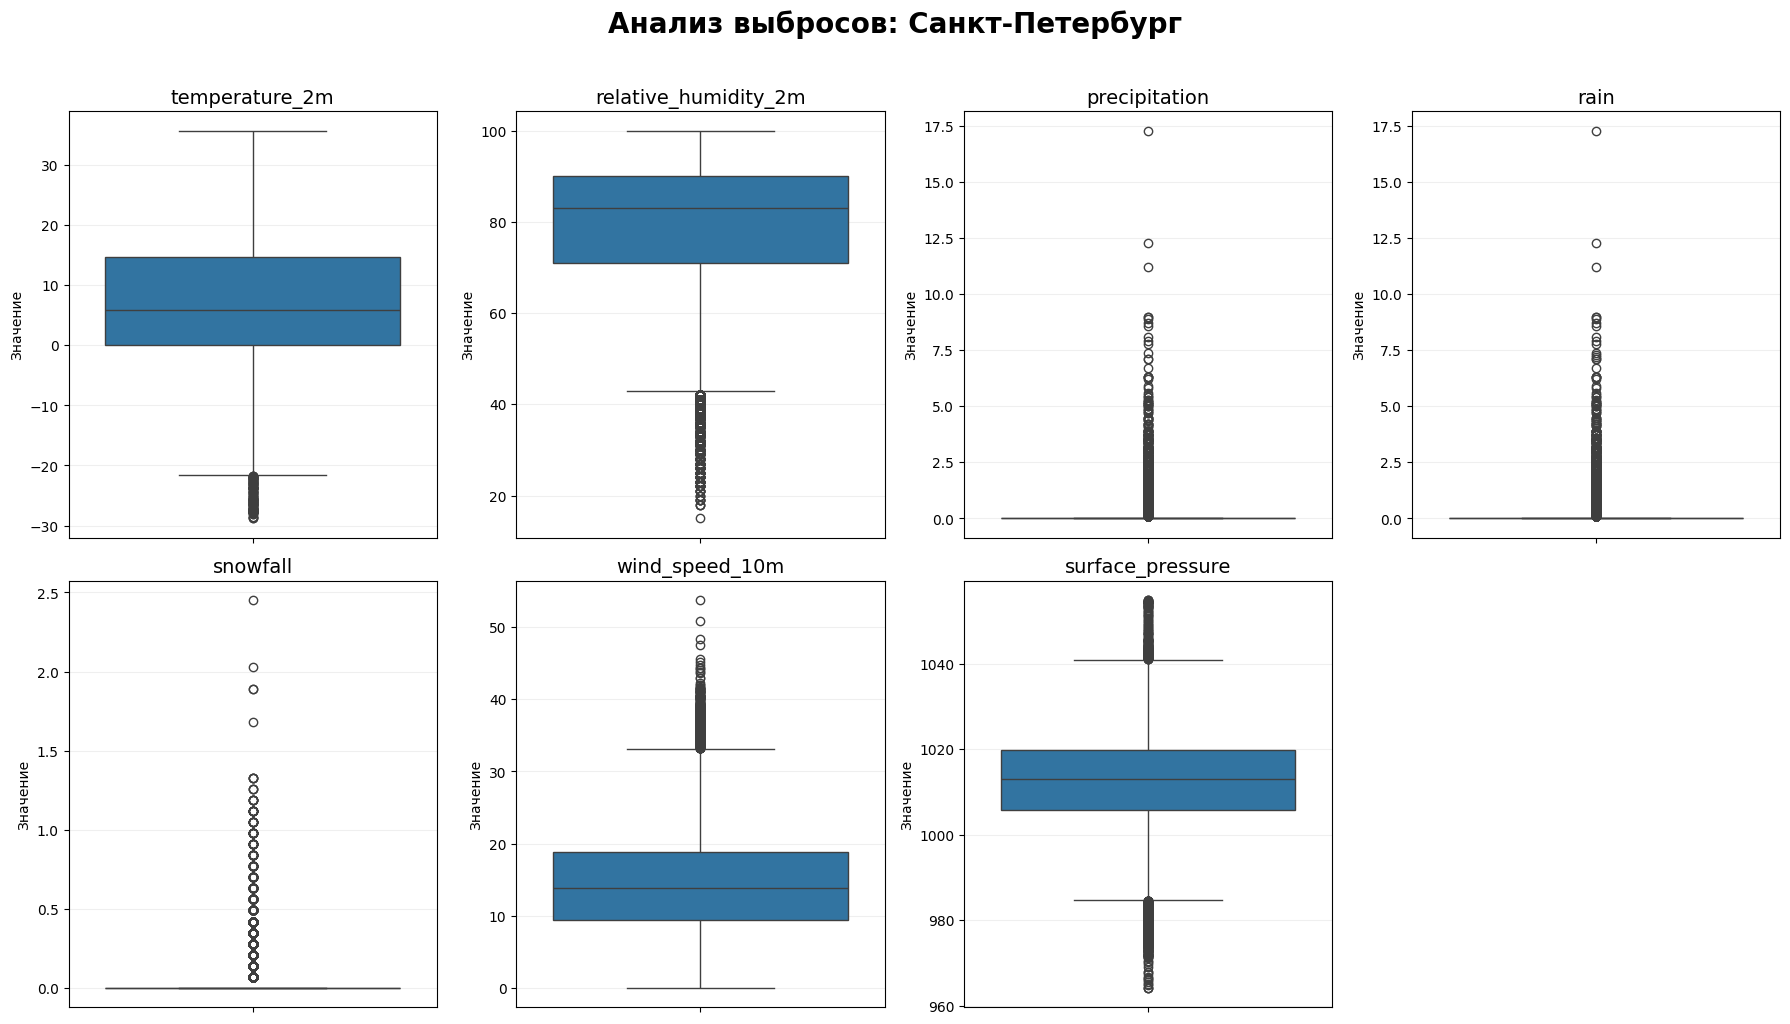

In [93]:
numeric_cols = ['temperature_2m', 'relative_humidity_2m', 'precipitation', 
                'rain', 'snowfall', 'wind_speed_10m', 'surface_pressure']
plot_single_city_diagnostic(df_resampled, 'Санкт-Петербург', numeric_cols)